# LIBS Spectra Classification 
## Objective

This notebook presents a supervised machine learning workflow for the classification of Laser-Induced Breakdown Spectroscopy (LIBS) spectra using TensorFlow.

The dataset consists of LIBS spectra acquired from different bone specimens. The primary objective is to classify spectra according to the individual from which the bone originated. Beyond standard train-test evaluation, the notebook also explores a more challenging question: whether a model trained on spectra from one bone specimen can correctly classify spectra acquired from different bones belonging to the same individual.

The focus of this notebook is to illustrate a deep learning workflow, including data loading, preprocessing, model construction, training, and evaluation, rather than to optimize the preprocessing pipeline or model architecture. 

In [5]:
# Standard library
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# Machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import accuracy_score, confusion_matrix

# Deep learning
import tensorflow as tf
from tensorflow.keras.regularizers import l2

# Local modules


project_root = Path.cwd().parent
sys.path.append(str(project_root))

from ML_libs.data_wrangling import condense_and_join
from ML_libs.plotters import plotters



### Set path to experimental data and print available folders:
The raw LIBS spectra are organized into separate directories, each corresponding to an independent experiment performed on a single bone sample.  
Every directory contains approximately 100 individual spectra acquired from the same specimen.  
The available experiments are first inspected before selecting the samples that will be used to construct the supervised learning dataset.

In [6]:
# Path containing the raw LIBS spectra
path_to_raw = "/home/redmati/Documents/ML-LIBS/raw_data/"
#path_to_raw = "/mnt/01D7F743B8136FB0/raw_data_LIBS"

# List available experiments
list_of_experiments = sorted(os.listdir(path_to_raw))

print("Available experiments:")
for exp in list_of_experiments:
    print(exp)

Available experiments:
F1-muestra 1-log_09ago.24_111305-ascii
F1-muestra 1-log_09ago.24_112021-ascii
F1-muestra 2-log_09ago.24_113401-ascii
N1-Muestra 1-log_24jul.24_161346-ascii
N1-muestra 2-log_08ago.24_102720-ascii
N1-muestra 2-log_08ago.24_103401-ascii
N3-muestra1-log_24jul.24_152442-ascii
N3-muestra1-log_24jul.24_152958-ascii
N3-muestra1-log_24jul.24_153633-ascii
N3-muestra2-log_24jul.24_155156-ascii
N3-muestra2-log_24jul.24_155927-ascii
N5-muestra 1-log_08ago.24_104941-ascii
N5-muestra 1-log_08ago.24_105457-ascii
N5-muestra 2-log_08ago.24_110232-ascii
N5-muestra 2-log_08ago.24_110914-ascii
Primera_prueba_RF.png


### A note on dataset construction
Each experiment contains approximately one hundred LIBS spectra.  
Individual spectra are first condensed on a single file and then merged into a single dataframe that will be used for supervised learning.

Here "F/N" idividual tag 

In [7]:
# Selected experiments used in this study
selected_experiments =["F1-muestra 1-log_09ago.24_111305-ascii",
            "N1-muestra 2-log_08ago.24_102720-ascii",
            "F1-muestra 1-log_09ago.24_112021-ascii",
            "N1-muestra 2-log_08ago.24_103401-ascii"]

seg = "Merge0" # part of the spectrum; "Merge_0" or name of spectrometer

condense_and_join.condense(selected_experiments, path_to_raw, seg, test=False)

/home/redmati/Documents/ML-LIBS/raw_data/F1-muestra 1-log_09ago.24_111305-ascii
/home/redmati/Documents/ML-LIBS/raw_data/N1-muestra 2-log_08ago.24_102720-ascii
/home/redmati/Documents/ML-LIBS/raw_data/F1-muestra 1-log_09ago.24_112021-ascii
/home/redmati/Documents/ML-LIBS/raw_data/N1-muestra 2-log_08ago.24_103401-ascii


### join each experiment to a single dataframe: 
Note that each row of the resulting dataframe corresponds to a single LIBS spectrum.  
The input features are the emission intensities measured at different wavelengths (the columns are labeled by their corresponding wavelength in nm).

In [8]:
df = condense_and_join.join_data(path_to_raw, selected_experiments, seg="Merge0")
print(df.shape)
df.head()

(400, 6085)


,211.53,211.62,211.72,211.81,211.91,212.0,212.09,212.19,212.28,212.38,...,636.61,636.66,636.71,636.75,636.8,636.85,636.9,636.94,file,experiment
0,210.22501,257.22501,240.22501,207.22501,203.22501,231.22501,224.22501,206.22501,239.22501,217.22501,...,361.64999,428.64999,402.64999,390.64999,389.64999,405.64999,413.64999,372.64999,log111449828_Merge0.TXT,F1-muestra 1-log_09ago.24_111305-ascii
1,198.89999,274.89999,239.89999,179.89999,211.89999,236.89999,238.89999,194.89999,218.89999,228.89999,...,354.32501,372.32501,354.32501,378.32501,374.32501,413.32501,388.32501,365.32501,log111528303_Merge0.TXT,F1-muestra 1-log_09ago.24_111305-ascii
2,216.12500,209.12500,223.12500,243.12500,219.12500,243.12500,235.12500,244.12500,238.12500,230.12500,...,367.54999,402.54999,351.54999,383.54999,397.54999,379.54999,408.54999,399.54999,log111427385_Merge0.TXT,F1-muestra 1-log_09ago.24_111305-ascii
3,234.50000,237.50000,215.50000,228.50000,200.50000,210.50000,218.50000,221.50000,237.50000,211.50000,...,384.79999,405.79999,336.79999,411.79999,368.79999,377.79999,411.79999,385.79999,log111336085_Merge0.TXT,F1-muestra 1-log_09ago.24_111305-ascii
4,184.14999,253.14999,231.14999,213.14999,216.14999,221.14999,209.14999,230.14999,237.14999,171.14999,...,404.57501,399.57501,321.57501,394.57501,384.57501,423.57501,385.57501,408.57501,log111307228_Merge0.TXT,F1-muestra 1-log_09ago.24_111305-ascii


### Path to save results:

In [11]:
results_dir = "/home/redmati/Documents/ML-LIBS/results_toshare"

## Spectral preprocessing

Prior to training, the spectra are normalized, restricted to the spectral region of interest, and corrected by subtracting a constant baseline.  
These preprocessing steps improve the signal-to-noise ratio and reduce the dimensionality of the classification problem.

The preprocessing pipeline presented here is intentionally simplified for demonstration purposes. More sophisticated workflows—including spectral denoising,  
advanced baseline correction, normalization strategies, and feature selection—have been proposed in the LIBS literature.  
The objective of this notebook is to illustrate a TensorFlow workflow rather than to optimize the preprocessing stage.

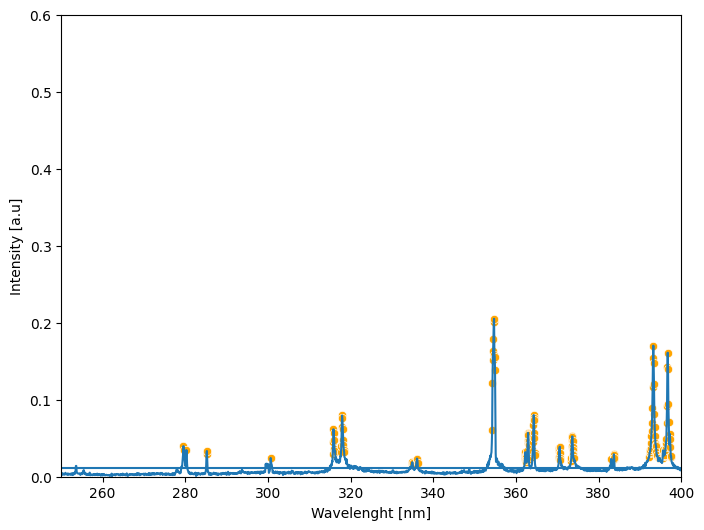

In [12]:
# Normalize spectra
df_norm = condense_and_join.normalize_dataframe(df)
# Select wavelength range (250–400 nm)
df_norm_zoom = condense_and_join.select_region(df_norm, xmin=250, xmax=400)
# Substract Baseline
df_base_zoom = condense_and_join.remove_baseline(df_norm_zoom, type="constant", level=0.011)
plotters.Plot_CompareBaseline(df_norm_zoom.drop(columns=["file", "experiment"]), 
                              df_base_zoom.drop(columns=["file", "experiment"]), 
                              results_dir, iloc=6, level=0.011, 
                              filename= "baseline_correction",
                              xmin=250, xmax =400,
                              ymin=0, ymax= 0.6)

### Define class labels
At this stage, each experiment is assigned to a classification label (tag). Multiple experiments may correspond to the same physical sample or experimental condition  
and are therefore grouped into the same class. These labels constitute the target variable used during supervised learning.


In [13]:
# Add tags : 

mapping = {'F1-muestra 1-log_09ago.24_111305-ascii': 0,
           'F1-muestra 1-log_09ago.24_112021-ascii': 0,
           'N1-muestra 2-log_08ago.24_102720-ascii': 1,
           'N1-muestra 2-log_08ago.24_103401-ascii': 1}

df_base_zoom["tag"] = df_base_zoom['experiment'].map(mapping)

In [14]:
print(f"Dataset shape: {df_base_zoom.shape}")
print(f"Number of features: {df_base_zoom.shape[1]-1}")
print("Number of classes:", df_base_zoom["tag"].nunique())
print(df_base_zoom["tag"].value_counts())

Dataset shape: (400, 165)
Number of features: 164
Number of classes: 2
tag
0    200
1    200
Name: count, dtype: int64


### Train-test split

Before training, the dataset is divided into independent training and testing subsets.  
The input features correspond to the preprocessed spectral intensities, while the target variable is the class label (tag) assigned to each spectrum. 
The test set is kept completely independent and is used only for the final evaluation of the classifier.

In [15]:
# Input features (spectral intensities)
X = df_base_zoom.drop(columns=["file", "experiment", "tag"])

# Target labels
y = df_base_zoom["tag"]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.75,
    random_state=127,
    stratify=y
)
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print("Training distribution")
print(y_train.value_counts(normalize=True))
print("Testing distribution")
print(y_test.value_counts(normalize=True))

Training samples: 300
Testing samples: 100
Training distribution
tag
1    0.5
0    0.5
Name: proportion, dtype: float64
Testing distribution
tag
0    0.5
1    0.5
Name: proportion, dtype: float64


RandmoForest (out of the box):

## Baseline model: Random Forest

As a baseline, a Random Forest classifier is trained using the same training set.  
Five-fold cross-validation is performed to estimate the expected classification performance before fitting the final model on the complete training dataset.  
The Random Forest serves as a reference against which the neural network performance can be compared.

Mean CV accuracy: 0.993 ± 0.008
Test accuracy: 1.000


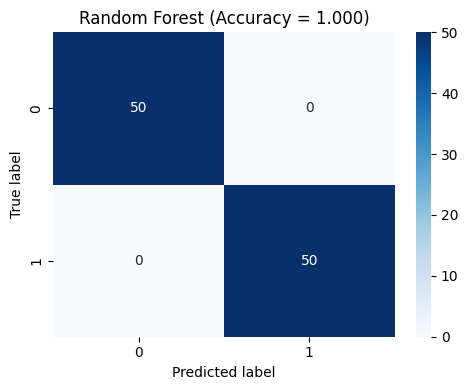

In [21]:
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=127
)

random_forest = RandomForestClassifier(
    n_estimators=50,
    random_state=127,
    n_jobs=-1
)

# Cross Validation
scores = cross_val_score(
    random_forest,
    X_train,
    y_train,
    cv=kfold,
    scoring="accuracy"
)

print(f"Mean CV accuracy: {scores.mean():.3f} ± {scores.std():.3f}")

## Train the model on the entire training set
random_forest.fit(X_train, y_train)
## Predict on the test set
y_pred = random_forest.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Test accuracy: {accuracy:.3f}")

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Random Forest (Accuracy = {accuracy:.3f})")

plt.tight_layout()
plt.savefig(os.path.join(results_dir, "confusion_matrix_RF.png"), dpi=300)
plt.show()

## Feedforward Neural Network

The main model considered in this notebook is a fully connected neural network implemented with TensorFlow/Keras. The network consists of two hidden layers with ReLU activation and dropout regularization to reduce overfitting.

Model performance is first estimated using five-fold cross-validation. A final model is then trained on the complete training dataset and evaluated on an independent test set.

In [22]:
def build_model(input_dim, n_classes):
    """
    Build a feedforward neural network for multi-class
    classification of LIBS spectra.
    """

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(n_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

### Five-fold cross-validation

Before training the final model, a five-fold cross-validation is performed to estimate the expected classification performance.

In [23]:
X_train_np = X_train.to_numpy()
y_train_np = y_train.to_numpy()

n_classes = len(np.unique(y_train_np))

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=127
)

fold_accuracies = []

for train_idx, val_idx in kfold.split(X_train_np):

    X_train_fold = X_train_np[train_idx]
    X_val_fold = X_train_np[val_idx]

    y_train_fold = y_train_np[train_idx]
    y_val_fold = y_train_np[val_idx]

    model = build_model(
        X_train_np.shape[1],
        n_classes
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    model.fit(
        X_train_fold,
        y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=100,
        batch_size=32,
        verbose=0,
        callbacks=[early_stop]
    )

    _, accuracy = model.evaluate(
        X_val_fold,
        y_val_fold,
        verbose=0
    )

    fold_accuracies.append(accuracy)

print(
    f"Mean CV accuracy: "
    f"{np.mean(fold_accuracies):.3f} ± "
    f"{np.std(fold_accuracies):.3f}"
)

I0000 00:00:1783434068.393574  136619 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-07-07 11:21:08.394614: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2343] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Mean CV accuracy: 1.000 ± 0.000


### Final model training

After cross-validation, the neural network is retrained using the complete training dataset.

In [24]:
model = build_model(
    X_train.shape[1],
    n_classes
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4702 - loss: 0.6996 - val_accuracy: 0.4833 - val_loss: 0.6782
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5904 - loss: 0.6670 - val_accuracy: 0.6000 - val_loss: 0.6564
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6666 - loss: 0.6469 - val_accuracy: 0.5667 - val_loss: 0.6342
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6709 - loss: 0.6244 - val_accuracy: 0.6167 - val_loss: 0.6122
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7253 - loss: 0.5834 - val_accuracy: 0.5833 - val_loss: 0.6025
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6939 - loss: 0.5799 - val_accuracy: 0.6500 - val_loss: 0.5759
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6955 - loss: 0.5503 - val_accuracy: 0.6333 - val_loss: 0.5637
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7393 - loss: 0.5200 - val_accuracy: 0.6667 - val_loss: 0.5366

### Learning curves

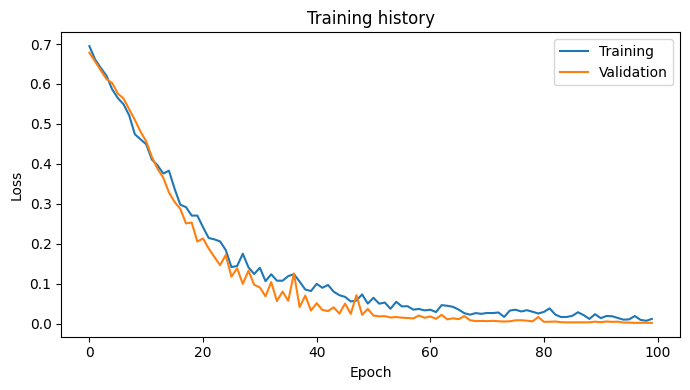

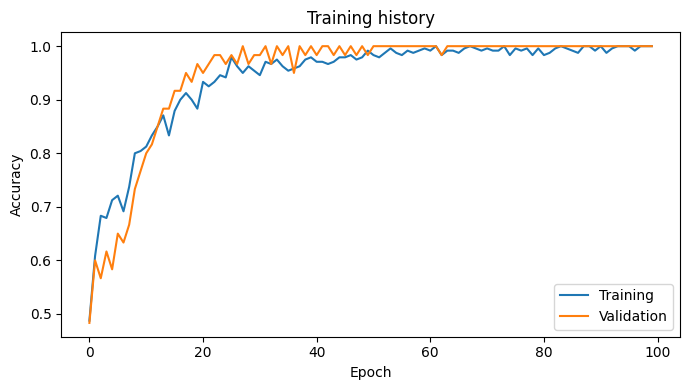

In [25]:
plt.figure(figsize=(7,4))

plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training history")
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(results_dir, "Training_History_Loss.png"), dpi=300)

plt.show()

plt.figure(figsize=(7,4))

plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training history")
plt.legend()
plt.savefig(os.path.join(results_dir, "Training_History_Accuracy.png"), dpi=300)

plt.tight_layout()
plt.show()

### Performance on the independent test set

The trained model is finally evaluated on the independent test set that was not used during optimization.

Test accuracy: 1.000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


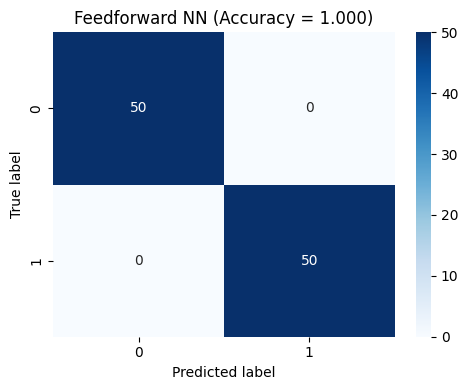

In [26]:
loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Test accuracy: {accuracy:.3f}")

y_pred = np.argmax(
    model.predict(X_test),
    axis=1
)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"Feedforward NN (Accuracy = {accuracy:.3f})")

plt.tight_layout()
plt.savefig(os.path.join(results_dir, "CM_NN.png"), dpi=300)

plt.show()

## Generalization across different bones of the same individual


The previous evaluation measures the model performance on spectra acquired from the same bone specimens used during training. Although the test set remains independent, all spectra originate from specimens represented in the training dataset.

A more demanding and scientifically relevant evaluation consists of testing whether the trained classifier can correctly identify spectra acquired from **different bone specimens belonging to the same individuals**.

To assess this, additional bone samples that were not included during training are processed using the same preprocessing pipeline and classified by the trained neural network.

_Training_

Individual F
    Bone F1 muestra 1 ---> used for training

Individual N
    Bone N1 muestra 2  ---> used for training


_Generalization test_

Individual F
    Bone F1 muestra 2  ---> never seen

Individual N
    Bone N1 muestra 1 ---> never seen

In [27]:
def load_specimen(experiments, feature_columns):
    """
    Load one or more experiments and return only the features used
    during model training.
    """

    df_specimen = condense_and_join.join_data(
        path_to_raw,
        experiments,
        seg="Merge0"
    )

    df_specimen = condense_and_join.normalize_dataframe(df_specimen)

    df_specimen = condense_and_join.select_region(
        df_specimen,
        xmin=250,
        xmax=400
    )

    return df_specimen[feature_columns]

In [28]:
F1_new = load_specimen(
    ["F1-muestra 2-log_09ago.24_113401-ascii"],
    X_train.columns
)

N1_new = load_specimen(
    ["N1-Muestra 1-log_24jul.24_161346-ascii"],
    X_train.columns
)

## NN
pred_F1 = np.argmax(
    model.predict(F1_new),
    axis=1
)
probs_F1 = model.predict(F1_new)

pred_N1 = np.argmax(
    model.predict(N1_new),
    axis=1
)
probs_N1 = model.predict(N1_new)

##

## RF
pred_F1_RF = random_forest.predict(F1_new)

pred_N1_RF = random_forest.predict(N1_new)

##

accuracy_F1 = np.mean(pred_F1 == 0)
accuracy_F1_RF = np.mean(pred_F1_RF == 0)


print(f"F1 accuracy [NN]: {accuracy_F1:.2%}")
print(f"F1 mean probabilities: {np.mean(probs_F1, axis=0)}")
print(f"F1 accuracy [RF]: {accuracy_F1_RF:.2%}")

accuracy_N1 = np.mean(pred_N1 == 1)
accuracy_N1_RF = np.mean(pred_N1_RF == 1)

print(f"N1 accuracy [NN]: {accuracy_N1:.2%}")
print(f"N1 mean probabilities: {np.mean(probs_N1, axis=0)}")
print(f"N1 accuracy [RF]: {accuracy_N1_RF:.2%}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 782us/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 635us/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 642us/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 625us/step
F1 accuracy [NN]: 94.00%
F1 mean probabilities: [0.91863906 0.08136088]
F1 accuracy [RF]: 92.00%
N1 accuracy [NN]: 97.00%
N1 mean probabilities: [0.04005122 0.9599488 ]
N1 accuracy [RF]: 92.00%


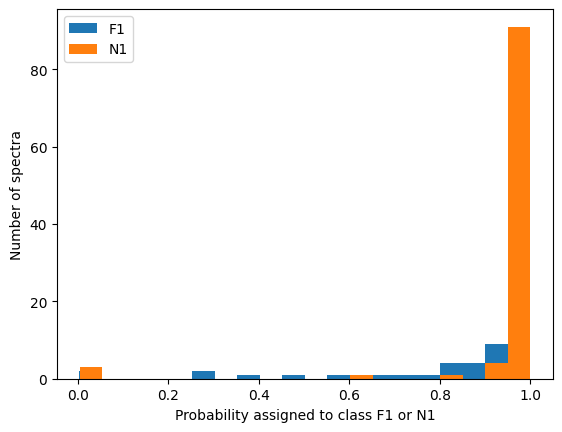

In [31]:
confidenceF1 = probs_F1[:,0]
confidenceN1 = probs_N1[:,1]

plt.hist(confidenceF1, bins=20)
plt.hist(confidenceN1, bins=20)


plt.xlabel("Probability assigned to class F1 or N1")
plt.ylabel("Number of spectra")
plt.legend(["F1", "N1"])
plt.savefig(os.path.join(results_dir, "Class_probabilities.png"), dpi=300)


In [32]:
summary = pd.DataFrame({
    "Specimen": ["F1", "N1"],
    "Expected class": [0, 1],
    "Predicted class_NN": [
        np.bincount(pred_F1).argmax(),
        np.bincount(pred_N1).argmax()
    ],
    "Predicted class_RF": [
        np.bincount(pred_F1_RF).argmax(),
        np.bincount(pred_N1_RF).argmax()
    ]
})

summary

,Specimen,Expected class,Predicted class_NN,Predicted class_RF
0,F1,0,0,0
1,N1,1,1,1


### Discussion

Both Random Forest and the Feedforward Neural Network achieved excellent performance on the independent test set. More importantly, both models were able to correctly classify spectra acquired from previously unseen bones belonging to the same individuals, suggesting that the learned representations capture spectral characteristics that extend beyond the specific training specimens.

Although these preliminary results are encouraging, the evaluation was performed on a limited number of individuals and bone samples. Future work will focus on expanding the dataset, assessing the robustness of the models under more diverse experimental conditions, and investigating the interpretability of the learned representations to better understand the spectral features driving the predictions.